In [1]:
import fitsio
import numpy as np
import matplotlib.pyplot as plt
from xlens.catalog.utils import _moments_to_ell

In [2]:
field = "spring1"
mag_zero = 27.0

import sys
sys.path.insert(0, ".")
from selection import MAG_CUTS_MULTIBAND, COMBINED_MAG_CUT
mag_cuts = MAG_CUTS_MULTIBAND
combined_mag_cut = COMBINED_MAG_CUT

C0 = 0.53
bands_all = list("grizy")

base = (
    "/gpfs02/work/xiangchong.li/work/hsc_data/s23b/"
    "deepCoadd_anacal_v2/fields"
)


In [3]:
d1 = fitsio.read(f"{base}/{field}.fits")
d2 = fitsio.read(f"{base}/{field}_multiband.fits")

# Photo-z selection
zbin = fitsio.read(
    f"/gpfs02/work/xiangchong.li/work/hsc_data/s23b/"
    f"deepCoadd_anacal_v2/fields_redshift/{field}.fits"
)
zbest = zbin["zbest_0"]
zmask = (zbest > 0.3) & (zbest < 1.5)
d1 = d1[zmask]
d2 = d2[zmask]


In [4]:
# Compute magnitudes for all bands
def get_mag(flux):
    mag = np.full(len(flux), 40.0)
    pos = flux > 0
    mag[pos] = mag_zero - 2.5 * np.log10(flux[pos])
    return mag

mags = {}
for b in bands_all:
    mags[b] = get_mag(d1[f"{b}_flux_gauss2"])

# Compute m2/m0 from i-band moments via _moments_to_ell
bands_riz = ["r", "i", "z"]
weights = {"r": 0.0, "i": 1.0, "z": 0.0}
moment_names = [
    "m00", "dm00_dg1", "dm00_dg2",
    "m20", "dm20_dg1", "dm20_dg2",
    "m22c", "dm22c_dg1", "dm22c_dg2",
    "m22s", "dm22s_dg1", "dm22s_dg2",
]
avg = {}
for mn in moment_names:
    avg[mn] = sum(weights[b] * d2[f"{b}_fpfs1_{mn}"] for b in bands_riz)

nobj = len(d2)
ell = _moments_to_ell(
    nobj, C0, "fpfs1_",
    avg["m00"], avg["m20"], avg["m22c"], avg["m22s"],
    avg["dm00_dg1"], avg["dm00_dg2"],
    avg["dm20_dg1"], avg["dm20_dg2"],
    avg["dm22c_dg1"], avg["dm22c_dg2"],
    avg["dm22s_dg1"], avg["dm22s_dg2"],
)
trace = ell["fpfs1_m2"] / ell["fpfs1_m0"]

mag_range = (18, 28)
nbins = 100

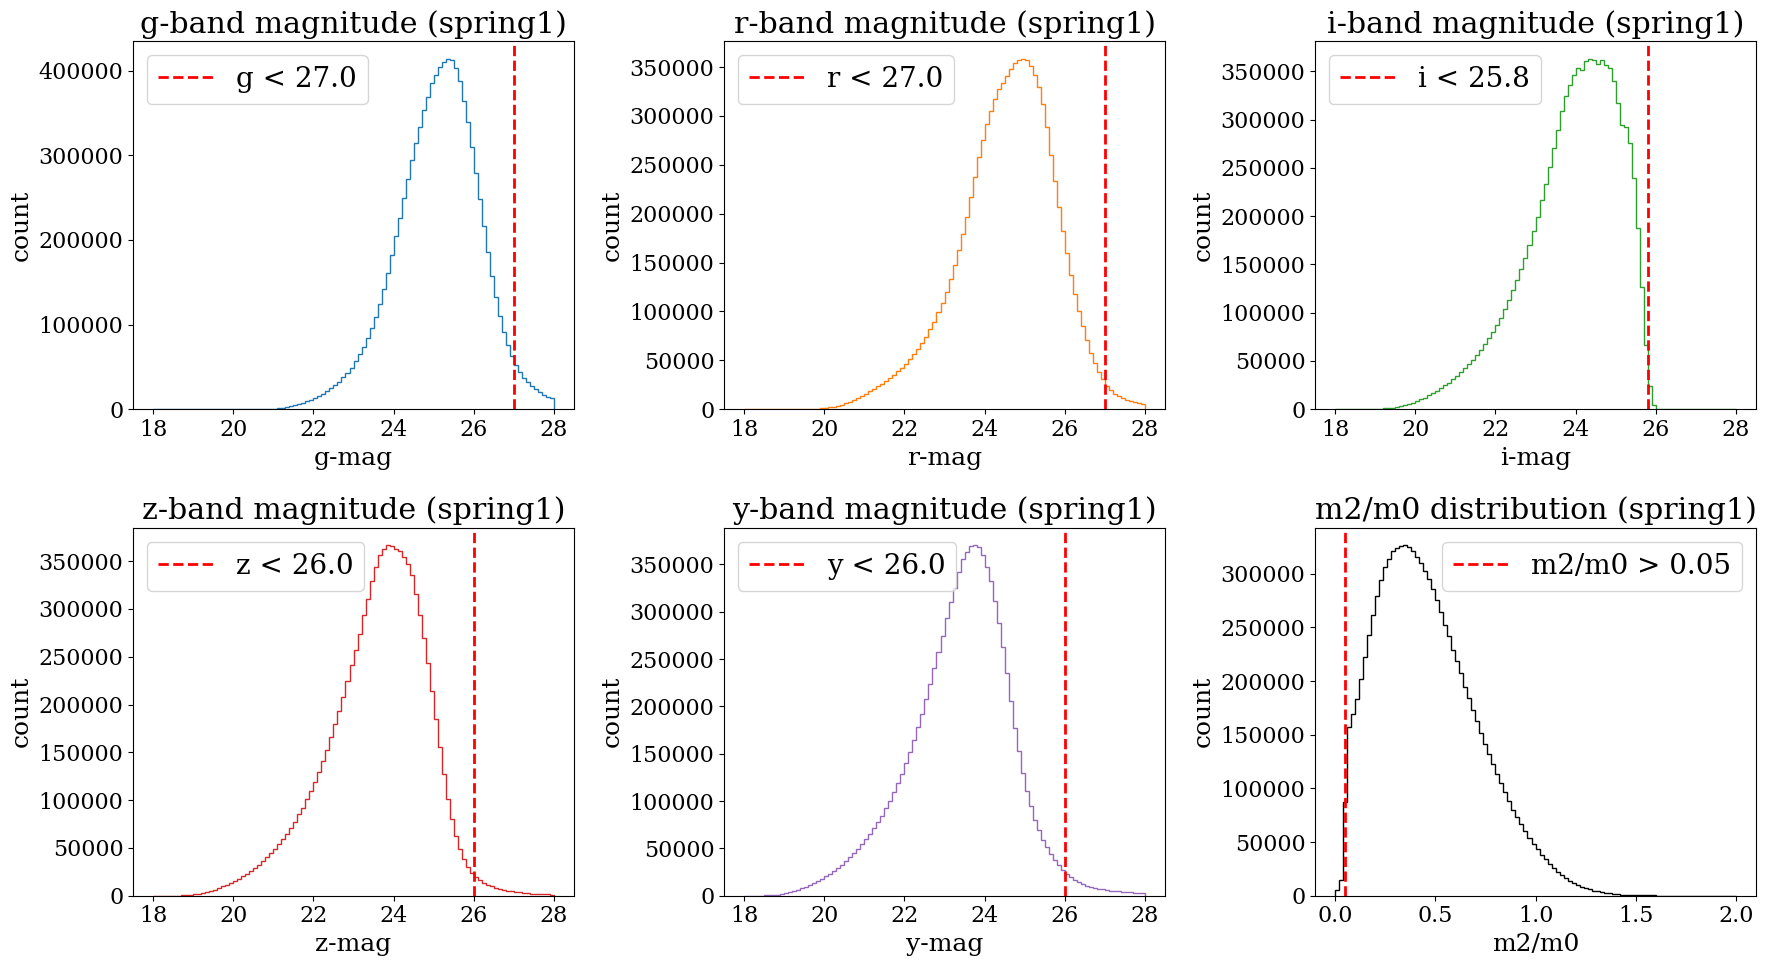

In [5]:
# 1D magnitude histograms for g, r, i, z, y
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors = {"g": "C0", "r": "C1", "i": "C2", "z": "C3", "y": "C4"}

for idx, b in enumerate(bands_all):
    ax = axes.flat[idx]
    ax.hist(mags[b], bins=nbins, range=mag_range, histtype="step",
            color=colors[b], lw=1.5)
    ax.axvline(mag_cuts[b], color="r", ls="--",
               label=f"{b} < {mag_cuts[b]}")
    ax.set_xlabel(f"{b}-mag")
    ax.set_ylabel("count")
    ax.set_title(f"{b}-band magnitude ({field})")
    ax.legend()

# m2/m0 histogram in the 6th panel
ax = axes.flat[5]
trace_range = (0, 2.0)
ax.hist(trace, bins=nbins, range=trace_range, histtype="step",
        color="k", lw=1.5)
ax.axvline(0.05, color="r", ls="--", label="m2/m0 > 0.05")
ax.set_xlabel("m2/m0")
ax.set_ylabel("count")
ax.set_title(f"m2/m0 distribution ({field})")
ax.legend()

plt.tight_layout()
plt.show()

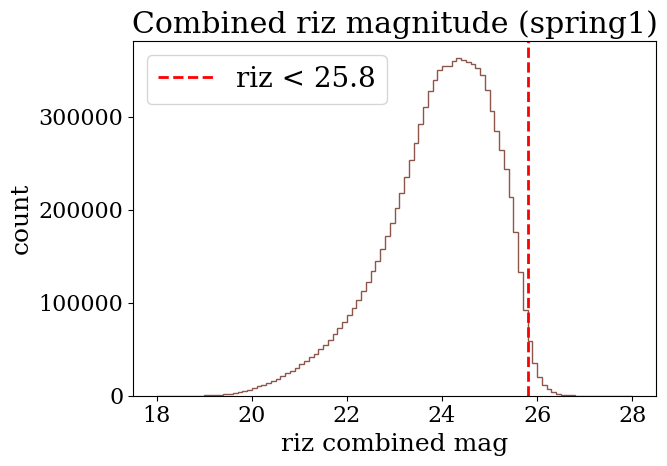

In [6]:
# Combined riz magnitude histogram
riz_weights = {"r": 0.2215, "i": 0.5593, "z": 0.2192}
combined_flux = sum(
    riz_weights[b] * d1[f"{b}_flux_gauss2"] for b in "riz"
)
mag_riz = get_mag(combined_flux)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(mag_riz, bins=nbins, range=mag_range, histtype="step",
        color="C5", lw=1.5)
ax.axvline(combined_mag_cut, color="r", ls="--",
           label=f"riz < {combined_mag_cut}")
ax.set_xlabel("riz combined mag")
ax.set_ylabel("count")
ax.set_title(f"Combined riz magnitude ({field})")
ax.legend()
plt.tight_layout()
plt.show()


In [7]:
# Apply selection cuts via shared selection.get_cut
from selection import get_cut

# Build a dict wrapper so selection.get_cut can index by plain names
combined_flux = (
    0.2215 * d1["r_flux_gauss2"]
    + 0.5593 * d1["i_flux_gauss2"]
    + 0.2192 * d1["z_flux_gauss2"]
)
data = {
    "e1": ell["fpfs1_e1"],
    "e2": ell["fpfs1_e2"],
    "m0": ell["fpfs1_m0"],
    "m2": ell["fpfs1_m2"],
    "flux_gauss2": combined_flux,
}
for b in "grizy":
    data[f"{b}_flux_gauss2"] = d1[f"{b}_flux_gauss2"]

cut = get_cut(data, comp=1, dg_eff=0.0, zbin=None)
print(f"After cuts: {cut.sum()} / {len(d1)}")

After cuts: 8691391 / 10238770


In [8]:
class corner_plot:
    def __init__(self, xrange, yrange, bins=30, xlabel="x", ylabel="y", xlim=None, ylim=None):
        fig = plt.figure(figsize=(7, 7))
        gs = fig.add_gridspec(4, 4, wspace=0.05, hspace=0.05)
        self.ax_2d = fig.add_subplot(gs[1:4, 0:3])
        self.ax_2d.set_xlabel(xlabel)
        self.ax_2d.set_ylabel(ylabel)

        self.ax_top = fig.add_subplot(gs[0, 0:3], sharex=self.ax_2d)
        self.ax_top.set_ylabel("PDF")
        self.ax_top.tick_params(axis="x", labelbottom=False)

        self.ax_right = fig.add_subplot(gs[1:4, 3], sharey=self.ax_2d)
        self.ax_right.set_xlabel("PDF")
        self.ax_right.tick_params(axis="y", labelleft=False)

        self.range_2d = [xrange, yrange]
        self.range_x = xrange
        self.range_y = yrange
        self.bins = bins
        if xlim is None:
            xlim = self.range_x
        if ylim is None:
            ylim = self.range_y
        self.ax_2d.set_xlim(xlim)
        self.ax_2d.set_ylim(ylim)
        self.ax_top.set_xlim(xlim)
        self.ax_right.set_ylim(ylim)

    def make_plot(self, x, y, linestyles="-", levels=[0.1, 0.3, 0.6], color="black"):
        hist, xedges, yedges = np.histogram2d(
            x=x, y=y, bins=self.bins, range=self.range_2d, density=True,
        )
        xc = 0.5 * (xedges[:-1] + xedges[1:])
        yc = 0.5 * (yedges[:-1] + yedges[1:])
        X, Y = np.meshgrid(xc, yc)
        self.ax_2d.contour(X, Y, hist.T, levels=levels,
                           colors=color, linestyles=linestyles)
        self.ax_top.hist(x, bins=self.bins, histtype="step", color=color,
                         range=self.range_x, density=True, ls=linestyles)
        self.ax_right.hist(y, bins=self.bins, histtype="step", color=color,
                           range=self.range_y, density=True,
                           ls=linestyles, orientation="horizontal")
        plt.tight_layout()


/gpfs02/work/xiangchong.li/work/tmp/ipykernel_25622/2888676225.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


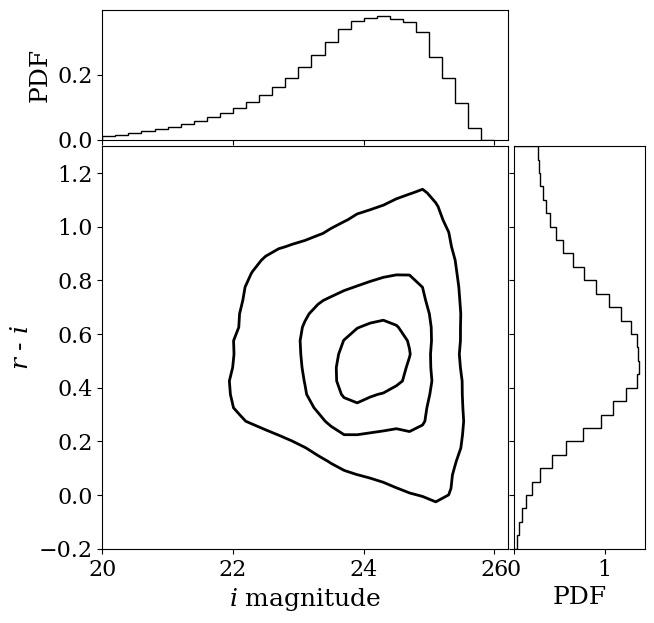

In [14]:
# 2D distributions of the selected sample (same style as 4_test_histogram.ipynb)
mag_i = mags["i"][cut]
mag_r = mags["r"][cut]
mag_z = mags["z"][cut]

# Shear response per object: (de1/dg1 + de2/dg2) / 2
res_arr = 0.5 * (ell["fpfs1_de1_dg1"] + ell["fpfs1_de2_dg2"])
res = res_arr[cut]
# Size proxy: m2/m0
size = (ell["fpfs1_m2"] / ell["fpfs1_m0"])[cut]


# --- i-mag vs (r - i) ---
plt.close()
xrange = [20.0, 26.0]
yrange = [-0.2, 1.3]
corp = corner_plot(
    xrange=xrange, yrange=yrange, bins=30,
    xlabel=r"$i$ magnitude", ylabel=r"$r$ - $i$",
    xlim=[20, 26.2], ylim=[-0.2, 1.3],
)
corp.make_plot(mag_i, mag_r - mag_i,
               linestyles="-", levels=[0.1, 0.3, 0.5])
plt.show()

/gpfs02/work/xiangchong.li/work/tmp/ipykernel_25622/2888676225.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


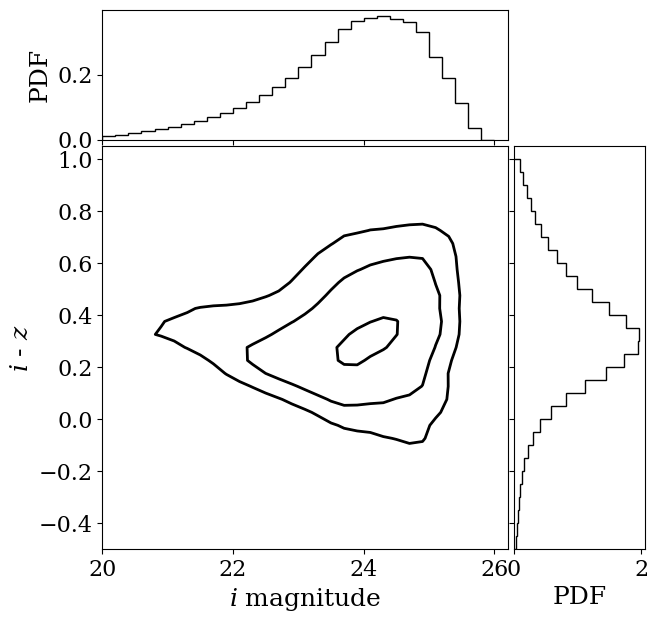

In [10]:
# --- i-mag vs (i - z) ---
plt.close()
xrange = [20.0, 26.0]
yrange = [-0.5, 1.0]
corp = corner_plot(
    xrange=xrange, yrange=yrange, bins=30,
    xlabel=r"$i$ magnitude", ylabel=r"$i$ - $z$",
    xlim=[20, 26.2], ylim=[-0.5, 1.05],
)
corp.make_plot(mag_i, mag_i - mag_z,
               linestyles="-", levels=[0.15, 0.3, 0.65])
plt.show()

/gpfs02/work/xiangchong.li/work/tmp/ipykernel_25622/2888676225.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


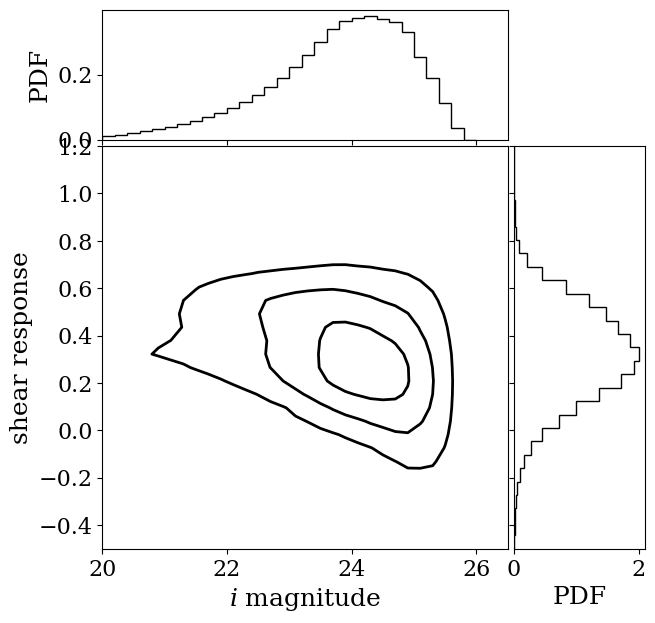

In [11]:
# --- i-mag vs shear response ---
plt.close()
xrange = [20.0, 26.0]
yrange = [-0.5, 1.2]
corp = corner_plot(
    xrange=xrange, yrange=yrange, bins=30,
    xlabel=r"$i$ magnitude", ylabel=r"shear response",
    xlim=[20.0, 26.5], ylim=[-0.5, 1.2],
)
corp.make_plot(mag_i, res, linestyles="-")
plt.show()

/gpfs02/work/xiangchong.li/work/tmp/ipykernel_25622/2888676225.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


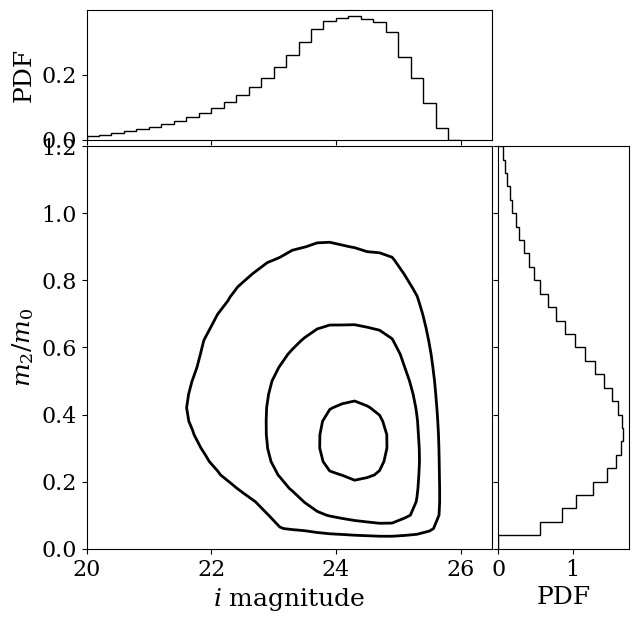

In [12]:
# --- i-mag vs size (m2/m0) ---
plt.close()
xrange = [20.0, 26.0]
yrange = [0.00, 1.2]
corp = corner_plot(
    xrange=xrange, yrange=yrange, bins=30,
    xlabel=r"$i$ magnitude", ylabel=r"$m_2/m_0$",
    xlim=[20.0, 26.5], ylim=[0.00, 1.2],
)
corp.make_plot(mag_i, size, linestyles="-")
plt.show()